In [1]:
import json
import random
import csv
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import pandas as pd

In [21]:
categories=["Filename","Arr_name","Gender","Age","Width","Height","X_min","X_max","Y_min","Y_max","Peace","Affection","Esteem","Anticipation","Engagement","Confidence","Happiness","Pleasure",
      "Excitement","Surprise","Sympathy","Doubt/Confusion","Disconnection","Fatigue","Embarrassment",
      "Yearning","Disapproval","Aversion","Annoyance","Anger","Sensitivity","Sadness","Disquietment","Fear","Pain","Suffering"]

all_data = json.load(open('./raw_data.json', 'r'))
for row in all_data:
    for item in row['items']:
        for key in categories:
            del item[key]
        del item['paramoji']['choices']
        item['paramoji']['value'] = np.round(item['paramoji']['value'],4).tolist()
f = open('raw_data_emotic.json','w')
f.write(json.dumps(all_data))
f.close()

In [2]:
all_data = json.load(open('./raw_data_emotic.json', 'r'))

In [3]:
len(all_data)

222

In [4]:
data = []
check_double = set()
for entry in all_data:
    unique_key = entry['workerId'] + entry['taskId']
    if unique_key in check_double:
        continue
    check_double.add(unique_key)
    data.extend(dict(item, 
                     worker=entry['workerId'],
                     paramoji_v=item['paramoji']['value'][0],
                     paramoji_a1=item['paramoji']['value'][1],
                     paramoji_a2=item['paramoji']['value'][2],
                     paramoji_p=item['paramoji']['value'][3],
                     paramoji_c=item['paramoji']['value'][4],
                    ) for item in entry['items'])
print(f"Doubles: {len(check_double)}")
print(f"Data: {len(data)}")
print(f"Workers: {len(set([r['worker'] for r in data]))}")

Doubles: 199
Data: 3980
Workers: 162


In [5]:
published = ['crop_arr_train_17022.npy', 'crop_arr_train_9210.npy', 'crop_arr_test_3959.npy']
P=[row for row in data if row['Crop_name'] in published]
if len(P) > 0:
    print(len(P)/3)
    f = open('raw_data_emotic_samples.json','w')
    f.write(json.dumps(all_data))
    f.close()

In [6]:
np.mean([row['paramoji']['iteration'] > 1.0 for row in data])

0.1849246231155779

In [7]:
faces_no = len(set([row['Crop_name'] for row in data]))
print(f"{len(data)}/{faces_no} = {len(data)/faces_no}")

3980/200 = 19.9


In [8]:
dims=["Valence","Arousal","Dominance"]
categories=["Peace","Affection","Esteem","Anticipation","Engagement","Confidence","Happiness","Pleasure",
      "Excitement","Surprise","Sympathy","Doubt/Confusion","Disconnection","Fatigue","Embarrassment",
      "Yearning","Disapproval","Aversion","Annoyance","Anger","Sensitivity","Sadness","Disquietment","Fear","Pain","Suffering"]
paramoji_dims=['paramoji_v','paramoji_a1','paramoji_a2','paramoji_p','paramoji_c']

In [85]:
results = pd.DataFrame(data) \
    .groupby('Crop_name')[dims + paramoji_dims] \
    .median().reset_index()
results

,Crop_name,Valence,Arousal,Dominance,paramoji_v,paramoji_a1,paramoji_a2,paramoji_p,paramoji_c
0,crop_arr_test_116.npy,5.500000,10.000000,7.500000,0.64130,0.36855,0.25270,0.52105,0.35925
1,crop_arr_test_1409.npy,5.000000,8.000000,5.000000,0.47090,0.53035,0.36530,0.45420,0.00000
2,crop_arr_test_1623.npy,5.000000,5.333334,4.333334,0.57355,0.47685,0.17545,0.41420,0.00000
3,crop_arr_test_1669.npy,3.666667,4.000000,5.000000,0.40950,0.42560,0.07920,0.35970,0.15540
4,crop_arr_test_2224.npy,3.000000,7.000000,8.000000,0.31930,0.45395,0.10205,0.41510,0.25470
...,...,...,...,...,...,...,...,...,...
195,crop_arr_train_9180.npy,7.000000,6.000000,6.000000,0.59350,0.56400,0.07360,0.51040,0.00000
196,crop_arr_train_9341.npy,7.000000,3.000000,3.000000,0.79135,0.63885,0.70930,0.63945,0.00000
197,crop_arr_train_9662.npy,7.000000,6.000000,7.000000,0.85290,0.51230,0.33030,0.62900,0.13180
198,crop_arr_train_9700.npy,5.000000,3.000000,2.000000,0.54600,0.58630,0.24350,0.30430,0.00000


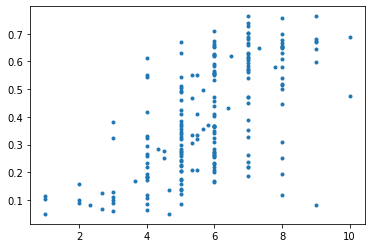

In [86]:
plt.plot(results['Valence'],results['paramoji_v']**2,'.')

In [87]:
C = results.corr()
C

,Valence,Arousal,Dominance,paramoji_v,paramoji_a1,paramoji_a2,paramoji_p,paramoji_c
Valence,1.000000,0.090479,0.463286,0.631839,0.156268,0.300599,0.177314,-0.133459
Arousal,0.090479,1.000000,0.326444,-0.037921,-0.028426,0.081278,0.092439,0.148152
Dominance,0.463286,0.326444,1.000000,0.186914,0.063294,0.047297,0.078740,0.023552
paramoji_v,0.631839,-0.037921,0.186914,1.000000,0.099653,0.218767,0.054844,-0.260087
paramoji_a1,0.156268,-0.028426,0.063294,0.099653,1.000000,0.066894,0.214120,-0.085707
paramoji_a2,0.300599,0.081278,0.047297,0.218767,0.066894,1.000000,0.033735,0.003471
paramoji_p,0.177314,0.092439,0.078740,0.054844,0.214120,0.033735,1.000000,0.175273
paramoji_c,-0.133459,0.148152,0.023552,-0.260087,-0.085707,0.003471,0.175273,1.000000


In [88]:
from sklearn import datasets, linear_model
X=results['Arousal'].values.reshape(-1,1)
Y=results[paramoji_dims].values
regr = linear_model.LinearRegression()
regr.fit(X,Y)
regr.coef_

array([[-0.00323832],
       [-0.00174245],
       [ 0.00765737],
       [ 0.00527786],
       [ 0.01124808]])

In [14]:
f = open('gen/emotic/results.json','w')
f.write(results.to_json(orient='records'))
f.close()

# Published data

In [40]:
print(C[paramoji_dims].loc[dims].to_latex( float_format="%.2f"))

\begin{tabular}{lrrrrr}
\toprule
{} &  paramoji\_v &  paramoji\_a1 &  paramoji\_a2 &  paramoji\_p &  paramoji\_c \\
\midrule
Valence   &        0.63 &         0.16 &         0.30 &        0.18 &       -0.13 \\
Arousal   &       -0.04 &        -0.03 &         0.08 &        0.09 &        0.15 \\
Dominance &        0.19 &         0.06 &         0.05 &        0.08 &        0.02 \\
\bottomrule
\end{tabular}



In [41]:
published = ['crop_arr_train_17022.npy', 'crop_arr_train_9210.npy', 'crop_arr_test_3959.npy']
M = results.loc[[row in published for row in results['Crop_name']]]
for i in range(M.shape[0]):
    row=M.iloc[i]
    print(f"%{row['Crop_name']}")
    file = [r['file'] for r in data if r['Crop_name'] == row['Crop_name']][0]
    print(f"\\face{{{file.replace('.jpg','')}}} &")
    v=row["paramoji_v"]*100
    a1=row["paramoji_a1"]*100
    a2=row["paramoji_a2"]*100
    p=row["paramoji_p"]*100
    c=row["paramoji_c"]*100
    print(f"\\paramoji{{{v:.0f},{(a1+a2)/2:.0f},{p:.0f},{c:.0f},{(a2-a1)/2+50:.0f}}} &")
    print(f"{v:.0f},{a1:.0f},{a2:.0f},{p:.0f},{c:.0f} \\\\")

In [42]:
M

,Crop_name,Valence,Arousal,Dominance,paramoji_v,paramoji_a1,paramoji_a2,paramoji_p,paramoji_c


In [192]:
# Check faces

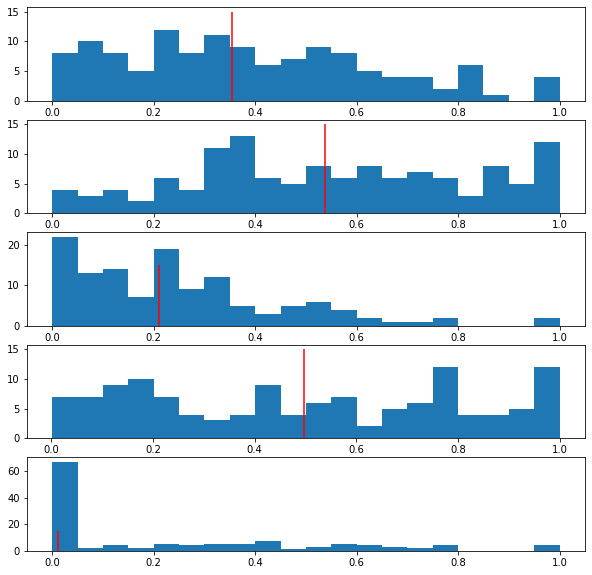

In [197]:
face="crop_arr_train_17022.npy"
DATA= [row for row in data if row['Crop_name']==face]
fig, ax = plt.subplots(5,1, figsize=(10,10))
for i in range(5):
    values = [row['paramoji']['value'][i] for row in DATA]
    ax[i].hist(values,20)
    ax[i].vlines(np.median(values), 0, 15, 'red')